# read

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../data/IMDb_Top_700_Movies_2026_cleaned.csv")

In [3]:
df.columns

Index(['Rank', 'Title', 'Year', 'Genre(s)', 'Director', 'Main Actor(s)',
       'Country', 'IMDb Rating', 'Votes', 'Runtime (mins)', 'Primary Genre',
       'Decade'],
      dtype='str')

In [ ]:
df['Votes'].quantile([0.25, 0.75])

0.3    234608.3
0.7    644037.9
Name: Votes, dtype: float64

In [23]:
df['Votes'].max()

np.int64(3219532)

# ML

## supervised

In [76]:
bins = [0, 192261, 728513, 3219532]
labels = ['Low', 'Medium', 'High']

df['Popularity'] = pd.cut(df['Votes'], bins=bins, labels=labels)

In [67]:
df['Popularity'].value_counts()

Popularity
Medium    280
Low       210
High      210
Name: count, dtype: int64

In [3]:
dfd= pd.get_dummies(df, columns=['Primary Genre'], dtype=int)
display(dfd)

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins),...,Primary Genre_Adventure,Primary Genre_Animation,Primary Genre_Biography,Primary Genre_Comedy,Primary Genre_Crime,Primary Genre_Documentary,Primary Genre_Drama,Primary Genre_Fantasy,Primary Genre_Horror,Primary Genre_Mystery
0,1,The Shawshank Redemption,1994,Drama,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,DK|AT,9.3,3219532,142,...,0,0,0,0,0,0,1,0,0,0
1,2,The Godfather,1972,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175,...,0,0,0,0,1,0,0,0,0,0
2,3,The Dark Knight,2008,Crime|Thriller,Christopher Nolan,Christian Bale|Heath Ledger|Aaron Eckhart,DK|LV,9.1,3205233,152,...,0,0,0,0,1,0,0,0,0,0
3,4,The Lord of the Rings: The Return of the King,2003,Adventure|Drama|Fantasy,Peter Jackson,Elijah Wood|Viggo Mortensen|Ian McKellen,DK|MK,9.0,2181911,201,...,1,0,0,0,0,0,0,0,0,0
4,5,Schindler's List,1993,Biography|Drama|History,Steven Spielberg,Liam Neeson|Ralph Fiennes|Ben Kingsley,DK|LV,9.0,1595992,195,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,696,The Count of Monte Cristo,2002,Action|Adventure|Drama,Kevin Reynolds,Jim Caviezel|Guy Pearce|Christopher Adamson,LV|DK,7.7,161156,131,...,0,0,0,0,0,0,0,0,0,0
696,697,The Cove,2009,Biography|Crime|Documentary,Louie Psihoyos,Ric O'Barry,DK|PT,8.4,52761,92,...,0,0,1,0,0,0,0,0,0,0
697,698,The Wages of Fear,1953,Adventure|Drama|Thriller,Henri-Georges Clouzot,Yves Montand|Charles Vanel|Peter van Eyck,DK|AT,8.1,74075,156,...,1,0,0,0,0,0,0,0,0,0
698,699,Good Bye Lenin!,2003,Comedy|Drama|Romance,Wolfgang Becker,Daniel Brühl|Katrin Sass|Chulpan Khamatova,PT|ZA,7.7,160485,121,...,0,0,0,1,0,0,0,0,0,0


In [69]:
dfd.columns

Index(['Rank', 'Title', 'Year', 'Genre(s)', 'Director', 'Main Actor(s)',
       'Country', 'IMDb Rating', 'Votes', 'Runtime (mins)', 'Decade',
       'Popularity', 'Primary Genre_Action', 'Primary Genre_Adventure',
       'Primary Genre_Animation', 'Primary Genre_Biography',
       'Primary Genre_Comedy', 'Primary Genre_Crime',
       'Primary Genre_Documentary', 'Primary Genre_Drama',
       'Primary Genre_Fantasy', 'Primary Genre_Horror',
       'Primary Genre_Mystery'],
      dtype='str')

In [7]:
x = dfd[["Year", "IMDb Rating", "Votes", "Runtime (mins)", 'Primary Genre_Action', 'Primary Genre_Adventure',
       'Primary Genre_Animation', 'Primary Genre_Biography',
       'Primary Genre_Comedy', 'Primary Genre_Crime',
       'Primary Genre_Documentary', 'Primary Genre_Drama',
       'Primary Genre_Fantasy', 'Primary Genre_Horror',
       'Primary Genre_Mystery']]
# y = df["Popularity"].values.ravel()
x.columns

Index(['Year', 'IMDb Rating', 'Votes', 'Runtime (mins)',
       'Primary Genre_Action', 'Primary Genre_Adventure',
       'Primary Genre_Animation', 'Primary Genre_Biography',
       'Primary Genre_Comedy', 'Primary Genre_Crime',
       'Primary Genre_Documentary', 'Primary Genre_Drama',
       'Primary Genre_Fantasy', 'Primary Genre_Horror',
       'Primary Genre_Mystery'],
      dtype='str')

In [103]:
display(y)

0      High
1      High
2      High
3      High
4      High
       ... 
695     Low
696     Low
697     Low
698     Low
699     Low
Name: Popularity, Length: 700, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

In [84]:
# from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [99]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

### RandomForest

In [100]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [101]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 52.86%


### KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)
knn_pred = knn_model.predict(x_test)
knn_acc = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy:                  {knn_acc * 100:.2f}%")

KNN Accuracy:                  40.71%


C:\Users\akmal\AppData\Roaming\Python\Python314\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


### logistic

In [88]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%")

C:\Users\akmal\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Logistic Regression Accuracy: 50.71%


C:\Users\akmal\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## you might like

In [ ]:
dfd= pd.get_dummies(df, columns=['Primary Genre'], dtype=int)
display(dfd)

In [ ]:
df_encoded[genre_columns] = df_encoded[genre_columns] * 3

In [8]:
x = dfd[["Year", "IMDb Rating", "Votes", "Runtime (mins)", 'Primary Genre_Action', 'Primary Genre_Adventure',
       'Primary Genre_Animation', 'Primary Genre_Biography',
       'Primary Genre_Comedy', 'Primary Genre_Crime',
       'Primary Genre_Documentary', 'Primary Genre_Drama',
       'Primary Genre_Fantasy', 'Primary Genre_Horror',
       'Primary Genre_Mystery']]
# y = df["Popularity"].values.ravel()
x.columns

Index(['Year', 'IMDb Rating', 'Votes', 'Runtime (mins)',
       'Primary Genre_Action', 'Primary Genre_Adventure',
       'Primary Genre_Animation', 'Primary Genre_Biography',
       'Primary Genre_Comedy', 'Primary Genre_Crime',
       'Primary Genre_Documentary', 'Primary Genre_Drama',
       'Primary Genre_Fantasy', 'Primary Genre_Horror',
       'Primary Genre_Mystery'],
      dtype='str')

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(x, Y=None, dense_output=True)
print(similarity_matrix)

[[1.         0.99999997 1.         ... 0.99966662 0.99992941 0.99988903]
 [0.99999997 1.         0.99999997 ... 0.99967333 0.99993247 0.99989288]
 [1.         0.99999997 1.         ... 0.99966681 0.99992949 0.99988914]
 ...
 [0.99966662 0.99967333 0.99966681 ... 1.         0.99990278 0.99994014]
 [0.99992941 0.99993247 0.99992949 ... 0.99990278 1.         0.99999544]
 [0.99988903 0.99989288 0.99988914 ... 0.99994014 0.99999544 1.        ]]


In [16]:
def get_recommendations(Title, df=df, n=5, cosine_sim=similarity_matrix):
    title_lower = Title.lower()
    df_titles_lower = df['Title'].str.lower()

    if title_lower not in df_titles_lower.values:
        return f"Judul '{Title}' tidak ditemukan dalam dataset."

    idx = df_titles_lower[df_titles_lower == title_lower].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    return df['Title'].iloc[movie_indices].reset_index(drop=True)

In [20]:
get_recommendations('The Godfather')

0                                           The Matrix
1    The Lord of the Rings: The Fellowship of the Ring
2        The Lord of the Rings: The Return of the King
3                                         Pulp Fiction
4                                         Forrest Gump
Name: Title, dtype: str

## 2

In [8]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['Genre(s)'].str.split('|'))
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df.index) * 3

other_features = df[['IMDb Rating', 'Runtime (mins)', 'Year', 'Votes']]
feature_matrix = pd.concat([other_features, genre_df], axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)

from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(scaled_features)

In [9]:
def get_recommendations(Title, df=df, n=5, cosine_sim=similarity_matrix):
    title_lower = Title.lower()
    df_titles_lower = df['Title'].str.lower()

    if title_lower not in df_titles_lower.values:
        return f"Judul '{Title}' tidak ditemukan dalam dataset."

    idx = df_titles_lower[df_titles_lower == title_lower].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    return df['Title'].iloc[movie_indices].reset_index(drop=True)

In [11]:
get_recommendations('Coco')

0                        The Lion King
1            A Silent Voice: The Movie
2    Spider-Man: Into the Spider-Verse
3                          Toy Story 3
4                                   Up
Name: Title, dtype: str

In [ ]:
import joblib

In [13]:
joblib.dump(similarity_matrix, 'similar_movie.joblib', compress=3)

['similar_movie.joblib']

In [14]:
joblib.dump(df['Title'].tolist(), 'titles.pkl')

['titles.pkl']

## Unsipervised


In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:
dfd= pd.get_dummies(df, columns=['Primary Genre'], dtype=int)
display(dfd)

In [5]:
x = dfd[["Year", "IMDb Rating", "Runtime (mins)", 'Primary Genre_Action', 'Primary Genre_Adventure',
       'Primary Genre_Animation', 'Primary Genre_Biography',
       'Primary Genre_Comedy', 'Primary Genre_Crime',
       'Primary Genre_Documentary', 'Primary Genre_Drama',
       'Primary Genre_Fantasy', 'Primary Genre_Horror',
       'Primary Genre_Mystery']]
x.columns

Index(['Year', 'IMDb Rating', 'Runtime (mins)', 'Primary Genre_Action',
       'Primary Genre_Adventure', 'Primary Genre_Animation',
       'Primary Genre_Biography', 'Primary Genre_Comedy',
       'Primary Genre_Crime', 'Primary Genre_Documentary',
       'Primary Genre_Drama', 'Primary Genre_Fantasy', 'Primary Genre_Horror',
       'Primary Genre_Mystery'],
      dtype='str')

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [9]:
print("Scaled training data:\n", X_scaled)

Scaled training data:
 [[-0.18931987  4.1078697   0.50341974 ... -0.03782347 -0.13206764
  -0.0758098 ]
 [-1.22063432  3.79184499  1.63817735 ... -0.03782347 -0.13206764
  -0.0758098 ]
 [ 0.46697115  3.47582029  0.84728568 ... -0.03782347 -0.13206764
  -0.0758098 ]
 ...
 [-2.11131499  0.31557324  0.98483206 ... -0.03782347 -0.13206764
  -0.0758098 ]
 [ 0.2325815  -0.94852558 -0.21869874 ... -0.03782347 -0.13206764
  -0.0758098 ]
 [-3.56453081 -0.63250087 -1.11275019 ... 26.43860813 -0.13206764
  -0.0758098 ]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [13]:
inertia_values = []
k_range = range(1, 20)

for k in k_range:
    kmeans = KMeans(n_init="auto", n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_) 

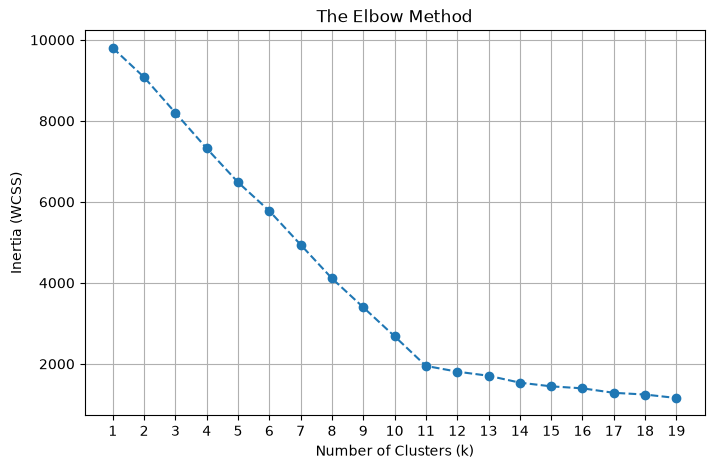

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [25]:
kmeans_final = KMeans(n_clusters=11, n_init="auto", random_state=42)

cluster_labels = kmeans_final.fit_predict(X_scaled)

In [26]:
dfd['Cluster'] = cluster_labels

cluster_summary = dfd.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

               Rank         Year  IMDb Rating         Votes  Runtime (mins)  \
Cluster                                                                       
0        366.325000  2007.781250     7.923750  5.947592e+05      132.593750   
1        418.750000  1995.250000     7.825000  4.961169e+05      110.916667   
2        352.369048  1993.613095     8.036310  4.676131e+05      128.511905   
3        349.075758  2005.090909     8.039394  4.459561e+05      137.363636   
4        300.582524  1995.077670     8.025243  6.397095e+05      126.058252   
5        369.313253  1993.650602     7.961446  4.136223e+05      114.698795   
6        350.912088  1991.956044     8.049451  6.231688e+05      128.582418   
7        559.500000  2018.000000     8.350000  7.110150e+04       90.000000   
8        120.750000  1990.750000     8.200000  1.066120e+06      127.000000   
9        700.000000  1922.000000     7.800000  1.239960e+05       95.000000   
10       362.800000  2002.100000     8.050000  2.601

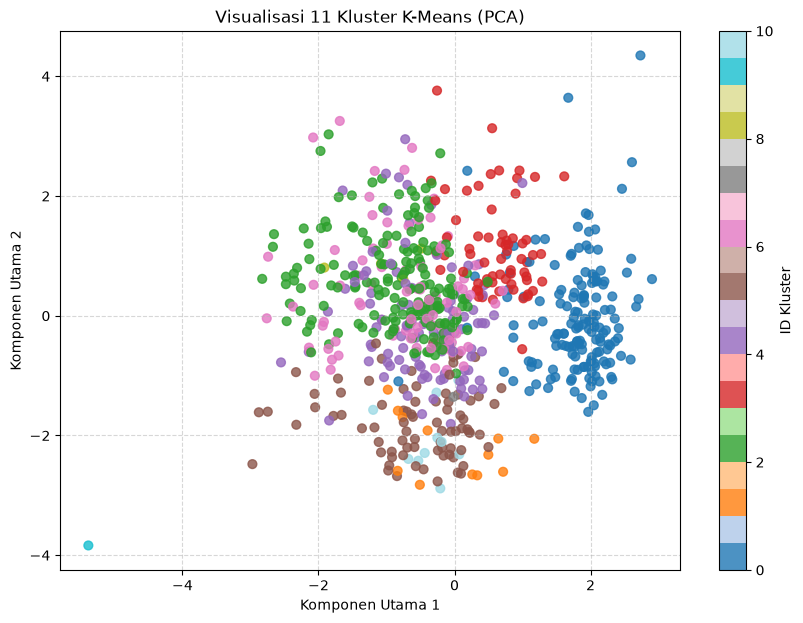

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduksi dimensi X_scaled menjadi 2 komponen utama
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot menggunakan palet warna 'tab20' yang cocok untuk banyak kluster
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab20', s=40, alpha=0.8)
plt.title('Visualisasi 11 Kluster K-Means (PCA)')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.colorbar(scatter, label='ID Kluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()